In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.datasets import mnist
from keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense

In [2]:
(train_images,train_labels),(test_images,test_labels) = mnist.load_data()
img_train = train_images / 255
img_test = test_images / 255
lbl_train = to_categorical(train_labels,10)
lbl_test = to_categorical(test_labels,10)

In [3]:
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28)
(10000, 28, 28)


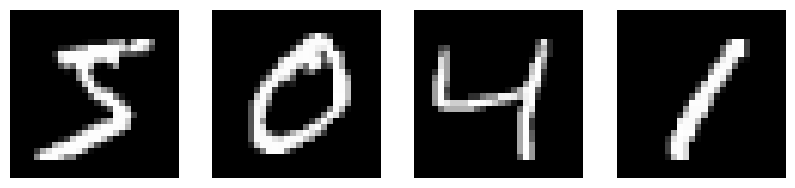

In [4]:
plt.figure(figsize=(10,5))
for i in range(4):
    plt.subplot(1,4,i+1)
    plt.imshow(train_images[i],cmap='gray')
    plt.axis("off")
plt.show()


In [5]:
for i in range(4):
    print(train_labels[i])
    print(lbl_train[i])

5
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
0
[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
4
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
1
[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


In [12]:
num,rows,cols = img_train.shape
img_train = img_train.reshape(-1,rows*cols)
print(img_train.shape)

(60000, 784)


In [7]:
model = Sequential([
    Input(shape=(28*28,)), # the size of the vectior
    Dense(128,activation='relu'), # can be 64 or 256 
    Dense(10,activation='softmax') # 10 cuz we have 10 classes
    # softmax returns a probabilty number from 0 to 1 the closer to 1 the closer to the right answet 0.10 -> 10%
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(img_train,lbl_train,epochs=8,batch_size=32)
# flatten imgs, categorial array, how many times the model will go over the train imgs, how freq the weight of the network will be updated

Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9265 - loss: 0.2569
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9661 - loss: 0.1142
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9765 - loss: 0.0791
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9820 - loss: 0.0593
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9852 - loss: 0.0464
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9887 - loss: 0.0365
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9908 - loss: 0.0290
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9931 - loss: 0.0228


In [17]:
img_test = img_test.reshape(-1,28*28)
print(img_test.shape)

(10000, 784)


In [18]:
evaluation = model.evaluate(img_test,lbl_test)
print(evaluation)
# the loss we got here is higher than the one we got on training
# overfitting prob

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9787 - loss: 0.0778
[0.07783838361501694, 0.9786999821662903]


In [19]:
predicitions = model.predict(img_test[:20,:]) # verctor of probs 
predicitions_idx = predicitions.argmax(1) # the idx of the closet prob to 1
print(predicitions_idx)
print(test_labels[:20])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


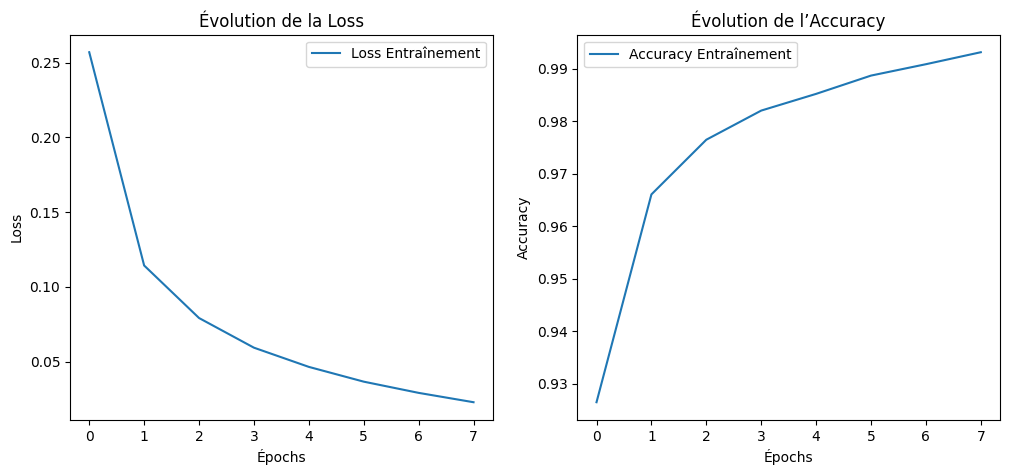

In [21]:
train_loss = history.history['loss']
train_acc = history.history['accuracy']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, label='Loss Entraînement')
plt.xlabel('Épochs')
plt.ylabel('Loss')
plt.title('Évolution de la Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Accuracy Entraînement')
plt.xlabel('Épochs')
plt.ylabel('Accuracy')
plt.title('Évolution de l’Accuracy')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


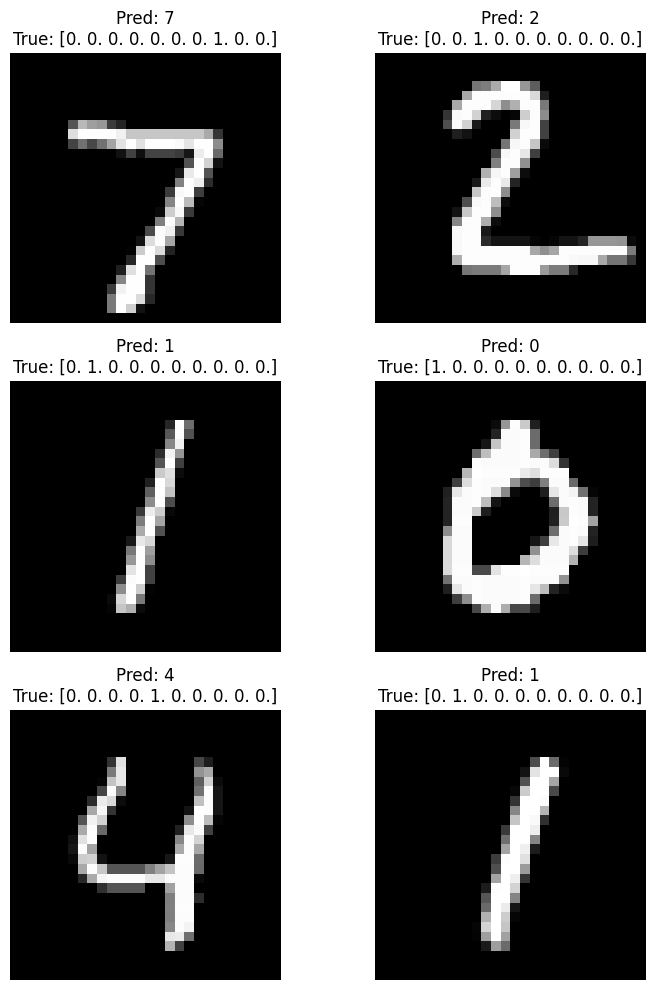

In [23]:
predictions = model.predict(img_test[:6])
pred_labels = np.argmax(predictions, axis=1)
plt.figure(figsize=(8, 10))
for i in range(6):
    plt.subplot(3, 2, i + 1)
    plt.imshow(img_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Pred: {pred_labels[i]}\nTrue: {lbl_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()